In [1]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

import numpy as np
import sklearn.metrics as metrics
import torch
import pickle
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from eb_dataset import EB_DS, load_dataset

import warnings

# import tonic
import numpy as np

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none' #for editable text in saved svg files

import pandas as pd

## Loading datasets

In [2]:
# ds_LUT = {'20250724':{'ds':'MNIST', 'dist':'D1'},
#           '20250803':{'ds':'FMNIST', 'dist':'D1'},
#           '20250730_2':{'ds':'KMNIST', 'dist':'D1'},
#           '20250809':{'ds':'MNIST', 'dist':'D2'},
#           '20250810_2':{'ds':'FMNIST', 'dist':'D2'},
#           '20250909':{'ds':'KMNIST', 'dist':'D2'}
#          }

# Suppress specific warning
warnings.filterwarnings("ignore", category=UserWarning, module='torch.nn.parallel.scatter_gather')

#load datasets
num_points = 1000
ds = {}
labels = {}
# ds['NMN'], labels['NMN'] , __ = load_dataset(tonic_name='NMNIST', tonic_train_split=True, tonic_path='/shareds/',
#                                                      n_samples=num_points, do_shuffle=False)

ds['D1'], labels['D1'], _ = load_dataset(base_path='../../datasets/eb_datasets/20250724/train/', n_samples=num_points, do_shuffle=False)
ds['D2'], labels['D2'], _ = load_dataset(base_path='../../datasets/eb_datasets/20250809/train/', n_samples=num_points, do_shuffle=False)
ds_frames, labels_frames, _ = load_dataset(base_path='../../datasets/eb_datasets/20250722/train/', frame_based=True, do_shuffle=False)
# ds['D1'], labels['D1'], _ = load_dataset(base_path='../../datasets/eb_datasets/20250803/train/', n_samples=num_points, do_shuffle=False)
# ds['D2'], labels['D2'], _ = load_dataset(base_path='../../datasets/eb_datasets/20250810_2/train/', n_samples=num_points, do_shuffle=False)
# ds_frames, labels_frames, _ = load_dataset(base_path='../../datasets/eb_datasets/20250728/train/', frame_based=True)

loading ../../datasets/eb_datasets/20250724/train/events.pkl...
../../datasets/eb_datasets/20250724/train/labels.pkl
loading ../../datasets/eb_datasets/20250809/train/events.pkl...
../../datasets/eb_datasets/20250809/train/labels.pkl
loading dataset from ../../datasets/eb_datasets/20250722/train/...
['../../datasets/eb_datasets/20250722/train/frames.pkl']
1  ds files found.
loading ../../datasets/eb_datasets/20250722/train/frames.pkl...
../../datasets/eb_datasets/20250722/train/labels.pkl


In [3]:
print(np.unique(labels['D1']))

[0 1 2 3 4 5 6 7 8 9]


In [4]:
for smpl in range(0,len(labels_frames)):
    if  (labels_frames[smpl]==6 and
        labels_frames[smpl+1]==7 and
        labels_frames[smpl+2]==7 and
        labels_frames[smpl+3]==0):
            print(smpl)
# print(smpl)
# print(labels_frames[1]==0 and labels_frames[2]==9)
# print(labels_frames[1])
# labels_frames[2]

15368
25916
27802
30283
43819
45986
51557
53466
53964
56920
58749


## Plotting MNIST D1 frames examples

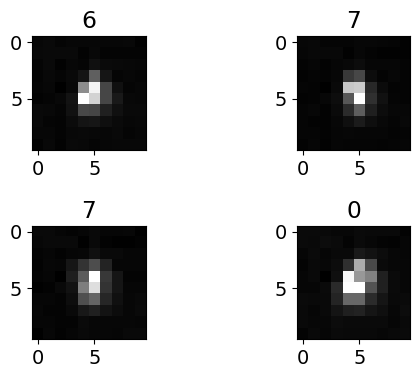

In [5]:
plt.rcParams.update({'font.size': 14})

#43819, 53466
first = 43819
samples_i= range(first, first+4)
# samples_i=[1,2,3,4]

fig, axs = plt.subplots(2,2, figsize=(6,4))

for plti, samplei in enumerate(samples_i):
    axs[plti//2,plti%2].imshow(ds_frames[samplei][-1][1], cmap='gray')
    axs[plti//2,plti%2].set_title(labels_frames[samplei])
    
plt.tight_layout()

# plt.savefig('fig1panelI.svg', bbox_inches='tight')

## Ploting event-based 3d raster plots

In [6]:
# %matplotlib notebook
#%matplotlib inline
# import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
def filter_by_interval_and_polarity(d,tmin,tmax,p):
    return np.logical_and(np.logical_and(d[:,0]>=tmin, d[:,0]<=tmax), np.abs(d[:,-1]-p)<1e-6)

In [8]:
tparams = {'NMN': [50,60,80],
          'D1': [100.,140, 140],
          'D2': [100.,140, 140],
          }
dd = {'NMN': 23,
          'D1': 8,
          'D2': 8,
          }

42 75 0
28 51 4
13 28 1
18 40 6


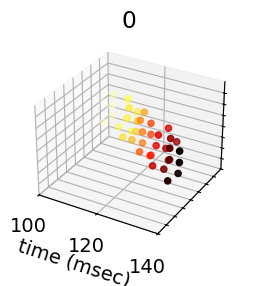

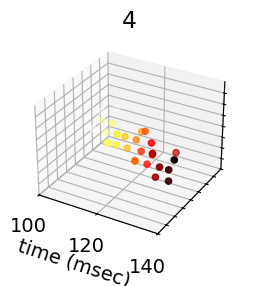

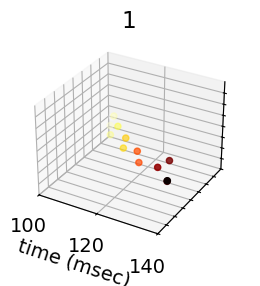

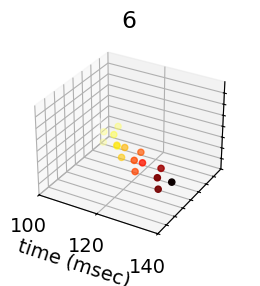

In [16]:
plt.rcParams.update({'font.size': 14})

eps = 1e-9
for this_ds in ds:

#     f= plt.figure(figsize=(12,4))

     for ii, uu in enumerate([4568, 10098]):
        tmin,tmax,tmaxshow = tparams[this_ds]
#         cm = plt.get_cmap("gray")

        f= plt.figure(figsize=(6,4))
        ax= f.add_subplot(1,2,ii+1,projection='3d')
        d = ds[this_ds][uu]
       
        iip = filter_by_interval_and_polarity(d,tmin,tmax,0)
        iin = filter_by_interval_and_polarity(d,tmin,tmax,1)

        print(np.sum(iip), np.sum(iin), labels[this_ds][uu])
                
        ax.set_xlim([tmin,tmaxshow])
        ax.set_xlabel('time (msec)')
        
        ax.set_title(labels[this_ds][uu])

        ax.axes.set_ylim3d(bottom=0.-eps, top=dd[this_ds]+eps) 
        ax.axes.set_zlim3d(bottom=0.-eps, top=dd[this_ds]+eps) 
            
        ax.set_yticks(np.arange(dd[this_ds]))
        ax.set_zticks(np.arange(dd[this_ds]))
        ax.set_yticklabels(['' for _ in ax.get_yticklabels()])
        ax.set_zticklabels(['' for _ in ax.get_zticklabels()])

#         ax.set_xticks([])
        ii = iip

        ax.scatter(d[ii,0], 2+np.max(d[ii,1]) - d[ii,1], 2+d[ii,2] - np.min(d[ii,2]),c = (-d[ii,0] + tmax+1e-9)**0.8, cmap='hot')
#         plt.tight_layout()
#         print(ax.xy_viewLim)

        if uu==10098:
#             file_name = 'fig1panelE.svg' if this_ds=='D1' else 'fig1panelF.svg'
#             plt.savefig(file_name, bbox_inches='tight')
            file_name_csv = 'fig1panelE.csv' if this_ds=='D1' else 'fig1panelF.csv'
            df = pd.DataFrame(d[ii,:], columns=['t', 'x', 'y','p'])
#             print(df)
            df.to_csv(file_name_csv, index=False)
        

### Histogram of number of events per trial

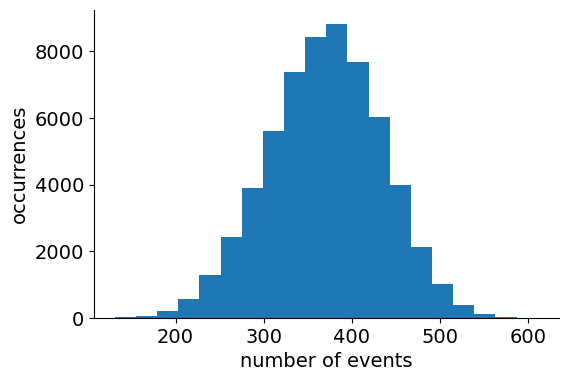

In [15]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(6,4))

#counting the number of elements in each sample_data up to the first zero timestamp
n_events_lst = [np.argmax(sample_data[:,0])+1 for sample_data in ds['D1']] 

_=plt.hist(n_events_lst, bins=20)
plt.xlabel('number of events')
plt.ylabel('occurrences')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('hist_test')

### Histogram of accumulation time of 48 events starting at t=100 

60000
0
         time  occurances
0   11.075017        65.0
1   12.689050       691.0
2   14.303083      2982.0
3   15.917117      6652.0
4   17.531150      9585.0
5   19.145183     10386.0
6   20.759217      8837.0
7   22.373250      6772.0
8   23.987283      4889.0
9   25.601317      3210.0
10  27.215350      2121.0
11  28.829383      1281.0
12  30.443417       859.0
13  32.057450       620.0
14  33.671483       387.0
15  35.285517       232.0
16  36.899550       136.0
17  38.513583       102.0
18  40.127617        69.0
19  41.741650        49.0
20  43.355683        19.0
21  44.969717         9.0
22  46.583750        17.0
23  48.197783        13.0
24  49.811817         6.0
25  51.425850         3.0
26  53.039883         3.0
27  54.653917         2.0
28  56.267950         2.0
29  57.881983         1.0


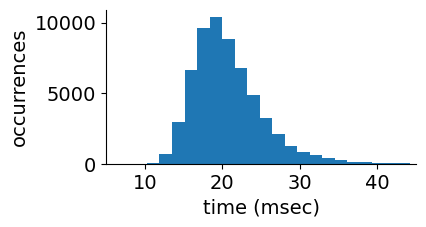

In [17]:
ti = 100.0 # time-window beginning
n_events = 48

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(4,2))

ts_lst_time_crop = [sample_data[:np.argmax(sample_data[:,0])+1,:] for sample_data in ds['D1']] #removing zero-padding
ts_lst_time_crop = [sample_data[sample_data[:,0]>ti,0] for sample_data in ts_lst_time_crop] #aligning all trials at time ti

# the time of the ''#n_events' event relative to 'ti'
n_events_acc_time = [ts_[n_events-1]-ti if len(ts_)>=n_events else 0.0 for ts_ in ts_lst_time_crop]

#is sorted ? - above computation assumes events are sorted by timestamp
for i, ts_ in enumerate(ts_lst_time_crop):
    time_diff = ts_[1:] - ts_[:-1]
    if (time_diff<0).any():
        print('{}, not sorted by timestamps!!!'.format(i))

print(len(n_events_acc_time))
print(np.sum(n_events_acc_time==0.0))

n_occ,bins,patches=plt.hist(n_events_acc_time, bins=30)
plt.xlabel('time (msec)')
plt.ylabel('occurrences')
plt.xlim([5,45])

time_ = (bins[:-1]+bins[1:])/2.0

# plt.title('48 events accumulation time')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('fig1panelG.svg', bbox_inches='tight')
file_name_csv = 'fig1panelG.csv' 
df = pd.DataFrame(np.array([time_, n_occ]).T, columns=['time', 'occurances'])
print(df)
df.to_csv(file_name_csv, index=False)

### Histogram of inter-event-interval: time difference between two consecutive events over all the pixels in the sensor

0.43051292801418495
0.4305129280141844
0.33200000000000784
   time  occurances
0   0.1    823432.0
1   0.3   1034611.0
2   0.5    124473.0
3   0.7    407343.0
4   0.9    137629.0
5   1.1    120672.0
6   1.3     67362.0
7   1.5     43880.0
8   1.7     24833.0


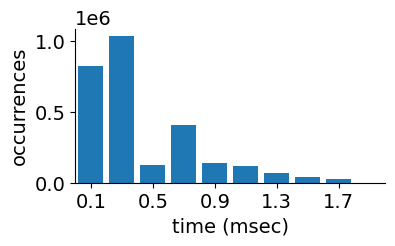

In [19]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(4,2))

ti = 100.0 # time-window beginning
n_events = 48
bin_width = 0.2
bins_= np.arange(0,2,bin_width)

hist_all = np.zeros([len(bins_)-1])
time_diffs_sum = 0
time_diffs_count = 0
time_diffs_all = []
for sample_data in ds['D1']:
    
    sample_ts = sample_data[:np.argmax(sample_data[:,0]),0] #removing zero-padding
    sample_ts = sample_ts[sample_ts[:]>ti]

    if sample_ts.shape[0]>=n_events:
        time_diffs = sample_ts[1:n_events] - sample_ts[0:n_events-1]
    else:
        time_diffs = sample_ts[1:] - sample_ts[:-1]
        
    time_diffs_sum+= np.sum(time_diffs)
    time_diffs_count+=len(time_diffs)
    time_diffs_all.append(time_diffs)
    
    # time_diffs = time_diffs[np.logical_and(time_diffs>1.0e-3,time_diffs<2.0)]
    hist, _ = np.histogram(time_diffs, bins=bins_)
    hist_all += hist

plt.bar(bins_[:-1]+bin_width/2, hist_all, width=bin_width*.8)
plt.xlabel('time (msec)')
plt.ylabel('occurrences')
plt.xlim([0,2])
plt.xticks(bins_[:-1:2]+bin_width/2)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

print(time_diffs_sum/time_diffs_count)
print(np.mean(time_diffs_all))
print(np.median(time_diffs_all))
# print(bins_[:-1])
# print(hist_all)

# plt.savefig('fig1panelH.svg', bbox_inches='tight')
file_name_csv = 'fig1panelH.csv' 
df = pd.DataFrame(np.array([bins_[:-1]+bin_width/2, hist_all]).T, columns=['time', 'occurances'])
print(df)
df.to_csv(file_name_csv, index=False)


### Plotting mean event rate and mean angular velocity along the trials

In [20]:
#load recroded events and IMU signals
def load_imu_data(ds_path = '', use_train = True):
    
    ds_path_set = os.path.join(ds_path,'train') if use_train else os.path.join(ds_path_,'test')
    with open(os.path.join(ds_path_set, 'imu.pkl'),'rb') as f:
        imu_lst = pickle.load(f)

    return imu_lst

ds_imu = load_imu_data(ds_path='../../datasets/eb_datasets/20250724/', use_train=True) #fbtMNISTD1
# ds_imu = load_imu_data(ds_path='../../datasets/eb_datasets/20250809/', use_train=True) #fbtMNISTD2
# ds_imu = load_imu_data(ds_path='../../datasets/eb_datasets/20250803/', use_train=True) #fbtKMNISTD1
# ds_imu = load_imu_data(ds_path='../../datasets/eb_datasets/20250810_2/', use_train=True) #fbtKMNISTD2

In [21]:
def get_event_rate(events, bins=range(0,400,1), space_crop = None, time_crop = None):
    
    timestamps = events[:,0]
#     timestamps = events['timestamp']
    
    if space_crop is not None:
        timestamps = timestamps[np.logical_and(np.logical_and(events[:,1]>=space_crop[0], 
                                                              events[:,1]<space_crop[2]),
                                               np.logical_and(events[:,2]>=space_crop[1],
                                                              events[:,2]<space_crop[3]))]
                                               
    if time_crop is not None:
        timestamps = timestamps[np.logical_and(timestamps>=time_crop[0], timestamps<time_crop[1])]
    
    rate,_ = np.histogram(timestamps, bins=bins)
        
    return rate

In [22]:
time_bins=range(0,401,1)

# events_rate = np.zeros([len(ds['D2']), len(time_bins)-1])
# imu_mat = np.zeros([len(ds['D2']), len(time_bins)-1])
events_rate = np.zeros([len(ds['D1']), len(time_bins)-1])
imu_mat = np.zeros([len(ds['D1']), len(time_bins)-1])

# for i,(events_padded,imu) in enumerate(zip(ds['D2'], ds_imu)):
for i,(events_padded,imu) in enumerate(zip(ds['D1'], ds_imu)):
    events = events_padded[:np.argmax(events_padded[:,0]),:] #removing zero-padding
    events_rate[i,:] = get_event_rate(events, bins=time_bins)
    n_samples=400
    if len(imu['gyroscope1'])<n_samples:
        n_samples=len(imu['gyroscope1'])
    imu_mat[i,:n_samples]=np.array(imu['gyroscope1'][:n_samples])

mean_rates = np.mean(events_rate, axis=0)
std_rates = np.std(events_rate, axis=0)
mean_imu = np.mean(imu_mat, axis=0)
std_imu = np.std(imu_mat, axis=0)
mean_imu_inverted = -1*mean_imu

      time  event rate mean  event rate std
0      0.0         0.118300        0.354596
1      1.0         0.116450        0.351173
2      2.0         0.116767        0.351945
3      3.0         0.113617        0.346758
4      4.0         0.116283        0.348943
..     ...              ...             ...
395  395.0         0.032550        0.188831
396  396.0         0.024750        0.167344
397  397.0         0.019300        0.148417
398  398.0         0.011917        0.116796
399  399.0         0.002550        0.052696

[400 rows x 3 columns]
      time  angular vel mean  angular vel std
0      0.0          1.379959         0.198264
1      1.0          1.387908         0.197079
2      2.0          1.394657         0.195985
3      3.0          1.400021         0.196200
4      4.0          1.403965         0.198506
..     ...               ...              ...
395  395.0          1.384240         2.434735
396  396.0          1.379734         2.436759
397  397.0          1.372610      

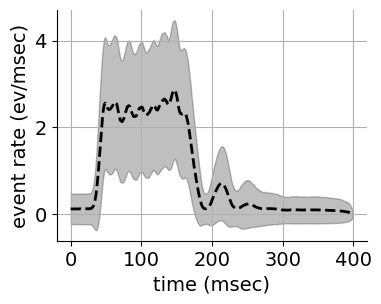

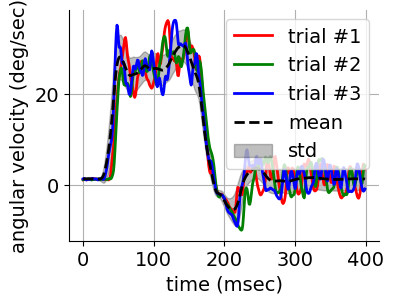

In [26]:
plt.rcParams.update({'font.size': 14})
# fig1, ax1 = plt.subplots(1,1, figsize=(6,4))
# fig2, ax2 = plt.subplots(1,1, figsize=(6,4))
fig1 = plt.figure(figsize=(4,3))
ax1 = plt.gca()
fig2 = plt.figure(figsize=(4,3))
ax2 = plt.gca()

# ax1.errorbar(time_bins[:-1], mean_rates, yerr=std_rates, fmt='r', ecolor='b')
ax1.plot(time_bins[:-1], mean_rates, 'k--', linewidth=2, label='mean')
ax1.fill_between(time_bins[:-1], mean_rates-std_rates, mean_rates+std_rates, color='k', alpha=0.25, label='Error Band')

ax1.set_xlabel('time (msec)')
ax1.set_ylabel('event rate (ev/msec)')
ax1.grid()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
                                
# markers, caps, bars = ax2.errorbar(time_bins[:-1], mean_imu, yerr=std_imu, fmt='r--', ecolor='b', linewidth=2)
# [bar.set_alpha(0.25) for bar in bars]
ax2.plot(time_bins[:-1], -1*imu_mat[10,:],'r', linewidth=2, label='trial #1')
ax2.plot(time_bins[:-1], -1*imu_mat[30000,:],'g', linewidth=2, label='trial #2')
ax2.plot(time_bins[:-1], -1*imu_mat[59999,:],'b', linewidth=2, label='trial #3')
ax2.plot(time_bins[:-1], mean_imu_inverted, 'k--', linewidth=2, label='mean')
ax2.fill_between(time_bins[:-1], mean_imu_inverted-std_imu, mean_imu_inverted+std_imu, 
                 color='k', alpha=0.25, label='std')

ax2.set_xlabel('time (msec)')
ax2.set_ylabel('angular velocity (deg/sec)')
ax2.grid()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend()

# fig1.savefig('fig1panelB.svg', bbox_inches='tight')
# fig2.savefig('fig1panelC.svg', bbox_inches='tight')

file_name_csv = 'fig1panelB.csv' 
df = pd.DataFrame(np.array([time_bins[:-1], mean_rates, std_rates]).T, columns=['time', 'event rate mean', 'event rate std'])
print(df)
df.to_csv(file_name_csv, index=False)

file_name_csv = 'fig1panelC_trial1.csv' 
df = pd.DataFrame(np.array([time_bins[:-1], -1*imu_mat[10,:]]).T, columns=['time', 'angular vel'])
df.to_csv(file_name_csv, index=False)
file_name_csv = 'fig1panelC_trial2.csv' 
df = pd.DataFrame(np.array([time_bins[:-1], -1*imu_mat[30000,:]]).T, columns=['time', 'angular vel'])
df.to_csv(file_name_csv, index=False)
file_name_csv = 'fig1panelC_trial3.csv' 
df = pd.DataFrame(np.array([time_bins[:-1], -1*imu_mat[59999,:]]).T, columns=['time', 'angular vel'])
df.to_csv(file_name_csv, index=False)
file_name_csv = 'fig1panelC_mean_std.csv' 
df = pd.DataFrame(np.array([time_bins[:-1], mean_imu_inverted, std_imu]).T, columns=['time', 'angular vel mean', 'angular vel std'])
print(df)
df.to_csv(file_name_csv, index=False)
                                                                      